In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [25]:
df = pd.read_csv('netflix_movies_dataset.csv')
df.head(5)


,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description
0,s1,Movie,Bird Box,Susanne Bier,"Sandra Bullock, Trevante Rhodes, John Malkovich",United States,2018,R,124 min,"Horror, Thriller",A woman and two children navigate a post-apoca...
1,s2,Movie,Extraction,Sam Hargrave,"Chris Hemsworth, Rudhraksh Jaiswal, Randeep Hooda",United States,2020,R,116 min,"Action, Thriller",A black-market mercenary's mission becomes a s...
2,s3,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci",United States,2019,R,209 min,"Crime, Drama",An aging hitman recalls his time working for t...
3,s4,Movie,Marriage Story,Noah Baumbach,"Scarlett Johansson, Adam Driver, Laura Dern",United States,2019,R,137 min,"Drama, Romance",A stage director and his actress wife battle d...
4,s5,Movie,Roma,Alfonso Cuaron,"Yalitza Aparicio, Marina de Tavira",Mexico,2018,R,135 min,Drama,A year in the life of a middle-class family's ...


In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       30 non-null     object
 1   type          30 non-null     object
 2   title         30 non-null     object
 3   director      30 non-null     object
 4   cast          30 non-null     object
 5   country       30 non-null     object
 6   release_year  30 non-null     int64 
 7   rating        30 non-null     object
 8   duration      30 non-null     object
 9   listed_in     30 non-null     object
 10  description   30 non-null     object
dtypes: int64(1), object(10)
memory usage: 2.7+ KB


In [69]:
df["rating_category"].head(5)


0    Mature
1    Mature
2    Mature
3    Mature
4    Mature
Name: rating_category, dtype: object

In [70]:
df.duplicated().sum() # has 13 duplicate movies


np.int64(0)

In [71]:
df.describe()


,release_year
count,30.0
mean,1970.0
std,0.0
min,1970.0
25%,1970.0
50%,1970.0
75%,1970.0
max,1970.0


Exploration summary
. we have a dataframe consisting of 45573 rows and 20 clmns


In [72]:
df.head (1)


,type,title,director,cast,country,release_year,rating,duration,listed_in,rating_category
0,Movie,Bird Box,Susanne Bier,"Sandra Bullock, Trevante Rhodes, John Malkovich",United States,1970,R,124 min,"Horror, Thriller",Mature


In [73]:
import pandas as pd

# Convert the 'id' column to datetime format
df['release_year'] = pd.to_datetime(df['release_year'], errors='coerce')

# Confirm the new data type
print(df['release_year'].dtypes)


datetime64[ns]


In [74]:
df['release_year'] = df['release_year'].dt.year
df['release_year'].dtypes


dtype('int32')

In [75]:
df.head(100)


,type,title,director,cast,country,release_year,rating,duration,listed_in,rating_category
0,Movie,Bird Box,Susanne Bier,"Sandra Bullock, Trevante Rhodes, John Malkovich",United States,1970,R,124 min,"Horror, Thriller",Mature
1,Movie,Extraction,Sam Hargrave,"Chris Hemsworth, Rudhraksh Jaiswal, Randeep Hooda",United States,1970,R,116 min,"Action, Thriller",Mature
2,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci",United States,1970,R,209 min,"Crime, Drama",Mature
3,Movie,Marriage Story,Noah Baumbach,"Scarlett Johansson, Adam Driver, Laura Dern",United States,1970,R,137 min,"Drama, Romance",Mature
4,Movie,Roma,Alfonso Cuaron,"Yalitza Aparicio, Marina de Tavira",Mexico,1970,R,135 min,Drama,Mature
5,Movie,Red Notice,Rawson Marshall Thurber,"Dwayne Johnson, Ryan Reynolds, Gal Gadot",United States,1970,PG-13,118 min,"Action, Comedy",Teen
6,Movie,Don't Look Up,Adam McKay,"Leonardo DiCaprio, Jennifer Lawrence, Meryl St...",United States,1970,R,138 min,"Comedy, Drama, Sci-Fi",Mature
7,Movie,The Gray Man,"Anthony Russo, Joe Russo","Ryan Gosling, Chris Evans, Ana de Armas",United States,1970,PG-13,129 min,"Action, Thriller",Teen
8,Movie,Glass Onion: A Knives Out Mystery,Rian Johnson,"Daniel Craig, Edward Norton, Janelle Monae",United States,1970,PG-13,139 min,"Comedy, Mystery",Teen
9,Movie,RRR,S. S. Rajamouli,"N. T. Rama Rao Jr., Ram Charan, Alia Bhatt",India,1970,Not Rated,187 min,"Action, Drama",Other


In [76]:
df.columns


Index(['type', 'title', 'director', 'cast', 'country', 'release_year',
       'rating', 'duration', 'listed_in', 'rating_category'],
      dtype='object')

In [80]:
# Dropping columns
cols = ['show_id', 'description']


df.columns


Index(['type', 'title', 'director', 'cast', 'country', 'release_year',
       'rating', 'duration', 'listed_in', 'rating_category'],
      dtype='object')

In [81]:
df.head()


,type,title,director,cast,country,release_year,rating,duration,listed_in,rating_category
0,Movie,Bird Box,Susanne Bier,"Sandra Bullock, Trevante Rhodes, John Malkovich",United States,1970,R,124 min,"Horror, Thriller",Mature
1,Movie,Extraction,Sam Hargrave,"Chris Hemsworth, Rudhraksh Jaiswal, Randeep Hooda",United States,1970,R,116 min,"Action, Thriller",Mature
2,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci",United States,1970,R,209 min,"Crime, Drama",Mature
3,Movie,Marriage Story,Noah Baumbach,"Scarlett Johansson, Adam Driver, Laura Dern",United States,1970,R,137 min,"Drama, Romance",Mature
4,Movie,Roma,Alfonso Cuaron,"Yalitza Aparicio, Marina de Tavira",Mexico,1970,R,135 min,Drama,Mature


In [82]:
def catigorize_col(df,col,labels):
    edges = [df[col].describe()['min'],
            df[col].describe()['25%'],
            df[col].describe()['50%'],
            df[col].describe()['75%'],
            df[col].describe()['max']]

    df[col] = pd.cut(df[col],edges,labels = labels,duplicates = 'drop')
    return df


In [83]:
labels = ['not_popular','below_avg','avg','popular']


In [ ]:
df['release_date'] = pd.to_datetime(
    df['release_year'].astype(str),
    format='%Y'
)

print(df[['release_year', 'release_date']].head())


   release_year release_date
0          1970   1970-01-01
1          1970   1970-01-01
2          1970   1970-01-01
3          1970   1970-01-01
4          1970   1970-01-01


In [100]:
def categorize_rating(rating):
    if rating in ['R', 'TV-MA']:
        return 'Mature'
    elif rating in ['PG-13', 'TV-14']:
        return 'Teen'
    elif rating in ['PG', 'TV-PG']:
        return 'Family'
    else:
        return 'Other'

df['rating_category'] = df['rating'].apply(categorize_rating)

print(df['rating_category'].unique())


['Mature' 'Teen' 'Other']


In [101]:
df.head()


,type,title,director,cast,country,release_year,rating,duration,listed_in,rating_category,release_date
0,Movie,Bird Box,Susanne Bier,"Sandra Bullock, Trevante Rhodes, John Malkovich",United States,1970,R,124 min,"Horror, Thriller",Mature,1970-01-01
1,Movie,Extraction,Sam Hargrave,"Chris Hemsworth, Rudhraksh Jaiswal, Randeep Hooda",United States,1970,R,116 min,"Action, Thriller",Mature,1970-01-01
2,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci",United States,1970,R,209 min,"Crime, Drama",Mature,1970-01-01
3,Movie,Marriage Story,Noah Baumbach,"Scarlett Johansson, Adam Driver, Laura Dern",United States,1970,R,137 min,"Drama, Romance",Mature,1970-01-01
4,Movie,Roma,Alfonso Cuaron,"Yalitza Aparicio, Marina de Tavira",Mexico,1970,R,135 min,Drama,Mature,1970-01-01


In [102]:
df['rating_category'].value_counts()


rating_category
Mature    19
Teen       7
Other      4
Name: count, dtype: int64

In [103]:
df.dropna(inplace =True)
df.isna().sum()


type               0
title              0
director           0
cast               0
country            0
release_year       0
rating             0
duration           0
listed_in          0
rating_category    0
release_date       0
dtype: int64

In [104]:
# Casting column into category
df['listed_in'] = df['listed_in'].astype('category')

print(df['listed_in'].dtypes)


category


In [105]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   type             30 non-null     object        
 1   title            30 non-null     object        
 2   director         30 non-null     object        
 3   cast             30 non-null     object        
 4   country          30 non-null     object        
 5   release_year     30 non-null     int32         
 6   rating           30 non-null     object        
 7   duration         30 non-null     object        
 8   listed_in        30 non-null     category      
 9   rating_category  30 non-null     object        
 10  release_date     30 non-null     datetime64[ns]
dtypes: category(1), datetime64[ns](1), int32(1), object(8)
memory usage: 3.1+ KB


In [106]:
df.nunique()


type                2
title              30
director           23
cast               30
country             6
release_year        1
rating              5
duration           24
listed_in          25
rating_category     3
release_date        1
dtype: int64

In [107]:
df.head(10)


,type,title,director,cast,country,release_year,rating,duration,listed_in,rating_category,release_date
0,Movie,Bird Box,Susanne Bier,"Sandra Bullock, Trevante Rhodes, John Malkovich",United States,1970,R,124 min,"Horror, Thriller",Mature,1970-01-01
1,Movie,Extraction,Sam Hargrave,"Chris Hemsworth, Rudhraksh Jaiswal, Randeep Hooda",United States,1970,R,116 min,"Action, Thriller",Mature,1970-01-01
2,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci",United States,1970,R,209 min,"Crime, Drama",Mature,1970-01-01
3,Movie,Marriage Story,Noah Baumbach,"Scarlett Johansson, Adam Driver, Laura Dern",United States,1970,R,137 min,"Drama, Romance",Mature,1970-01-01
4,Movie,Roma,Alfonso Cuaron,"Yalitza Aparicio, Marina de Tavira",Mexico,1970,R,135 min,Drama,Mature,1970-01-01
5,Movie,Red Notice,Rawson Marshall Thurber,"Dwayne Johnson, Ryan Reynolds, Gal Gadot",United States,1970,PG-13,118 min,"Action, Comedy",Teen,1970-01-01
6,Movie,Don't Look Up,Adam McKay,"Leonardo DiCaprio, Jennifer Lawrence, Meryl St...",United States,1970,R,138 min,"Comedy, Drama, Sci-Fi",Mature,1970-01-01
7,Movie,The Gray Man,"Anthony Russo, Joe Russo","Ryan Gosling, Chris Evans, Ana de Armas",United States,1970,PG-13,129 min,"Action, Thriller",Teen,1970-01-01
8,Movie,Glass Onion: A Knives Out Mystery,Rian Johnson,"Daniel Craig, Edward Norton, Janelle Monae",United States,1970,PG-13,139 min,"Comedy, Mystery",Teen,1970-01-01
9,Movie,RRR,S. S. Rajamouli,"N. T. Rama Rao Jr., Ram Charan, Alia Bhatt",India,1970,Not Rated,187 min,"Action, Drama",Other,1970-01-01


In [108]:
#Data visualizeation


In [109]:
sns.set_style("whitegrid")


In [110]:
df['listed_in'].describe()


count               30
unique              25
top       Crime, Drama
freq                 3
Name: listed_in, dtype: object

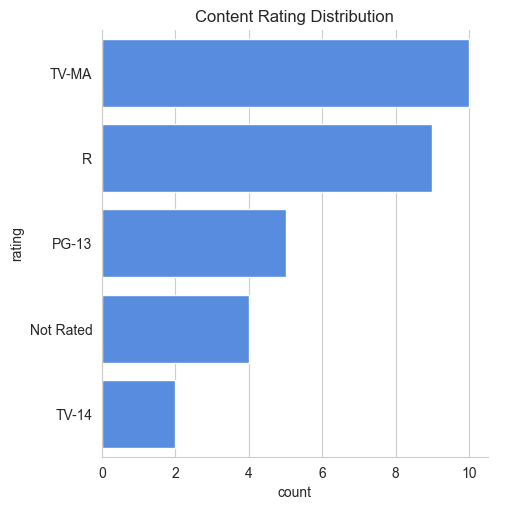

In [111]:
sns.catplot(
    y='rating',
    data=df,
    kind='count',
    order=df['rating'].value_counts().index,
    color="#4287f5"
)

plt.title("Content Rating Distribution")
plt.show()


In [112]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

movies[movies['duration_min'] == movies['duration_min'].max()]


,type,title,director,cast,country,release_year,rating,duration,listed_in,rating_category,release_date,duration_min
2,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci",United States,1970,R,209 min,"Crime, Drama",Mature,1970-01-01,209.0


In [113]:
df[df['release_year'] == df['release_year'].min()]


,type,title,director,cast,country,release_year,rating,duration,listed_in,rating_category,release_date
0,Movie,Bird Box,Susanne Bier,"Sandra Bullock, Trevante Rhodes, John Malkovich",United States,1970,R,124 min,"Horror, Thriller",Mature,1970-01-01
1,Movie,Extraction,Sam Hargrave,"Chris Hemsworth, Rudhraksh Jaiswal, Randeep Hooda",United States,1970,R,116 min,"Action, Thriller",Mature,1970-01-01
2,Movie,The Irishman,Martin Scorsese,"Robert De Niro, Al Pacino, Joe Pesci",United States,1970,R,209 min,"Crime, Drama",Mature,1970-01-01
3,Movie,Marriage Story,Noah Baumbach,"Scarlett Johansson, Adam Driver, Laura Dern",United States,1970,R,137 min,"Drama, Romance",Mature,1970-01-01
4,Movie,Roma,Alfonso Cuaron,"Yalitza Aparicio, Marina de Tavira",Mexico,1970,R,135 min,Drama,Mature,1970-01-01
5,Movie,Red Notice,Rawson Marshall Thurber,"Dwayne Johnson, Ryan Reynolds, Gal Gadot",United States,1970,PG-13,118 min,"Action, Comedy",Teen,1970-01-01
6,Movie,Don't Look Up,Adam McKay,"Leonardo DiCaprio, Jennifer Lawrence, Meryl St...",United States,1970,R,138 min,"Comedy, Drama, Sci-Fi",Mature,1970-01-01
7,Movie,The Gray Man,"Anthony Russo, Joe Russo","Ryan Gosling, Chris Evans, Ana de Armas",United States,1970,PG-13,129 min,"Action, Thriller",Teen,1970-01-01
8,Movie,Glass Onion: A Knives Out Mystery,Rian Johnson,"Daniel Craig, Edward Norton, Janelle Monae",United States,1970,PG-13,139 min,"Comedy, Mystery",Teen,1970-01-01
9,Movie,RRR,S. S. Rajamouli,"N. T. Rama Rao Jr., Ram Charan, Alia Bhatt",India,1970,Not Rated,187 min,"Action, Drama",Other,1970-01-01


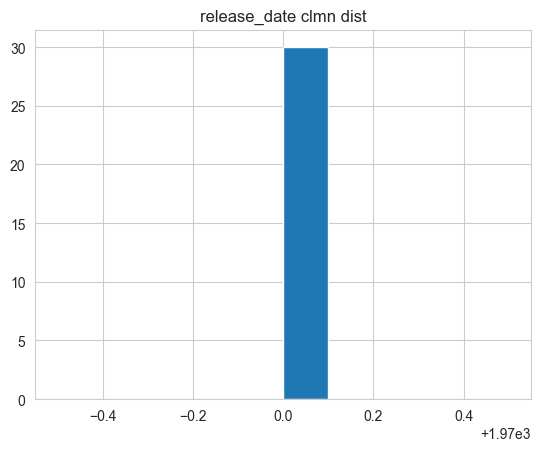

In [114]:
# q5
df['release_year'].hist()
plt.title("release_date clmn dist")
plt.show()


summary of whole project


The dataset includes content from multiple countries, allowing country-wise distribution to be examined.

The dataset contains 30 Netflix titles, consisting of both Movies and TV Shows.

The content-rating analysis shows that the dataset contains a substantial representation of mature-oriented content, while TV-14 and other classifications occur less frequently.

TV-MA is the most common content rating in the dataset, followed by R and PG-13.

The listed_in field shows that several titles belong to multiple genres, with categories such as Drama, Crime, Thriller, Action, Comedy, and Horror appearing across the dataset.
Movie durations vary considerably, ranging from relatively short films to longer productions such as The Irishman and RRR.

TV Shows are represented using season counts, whereas Movies are represented using runtime in minutes, so duration requires different interpretation for the two content types.

Release-year analysis can be used to examine the temporal distribution of the available titles, although conclusions are limited by the dataset's small size.
The analysis demonstrates the importance of data cleaning, correct data types, categorical analysis, and understanding the dataset schema before performing visualization or statistical analysis.